<div style="background:#0032A0; border-radius:10px; padding:14px 18px; margin-bottom:16px;">
  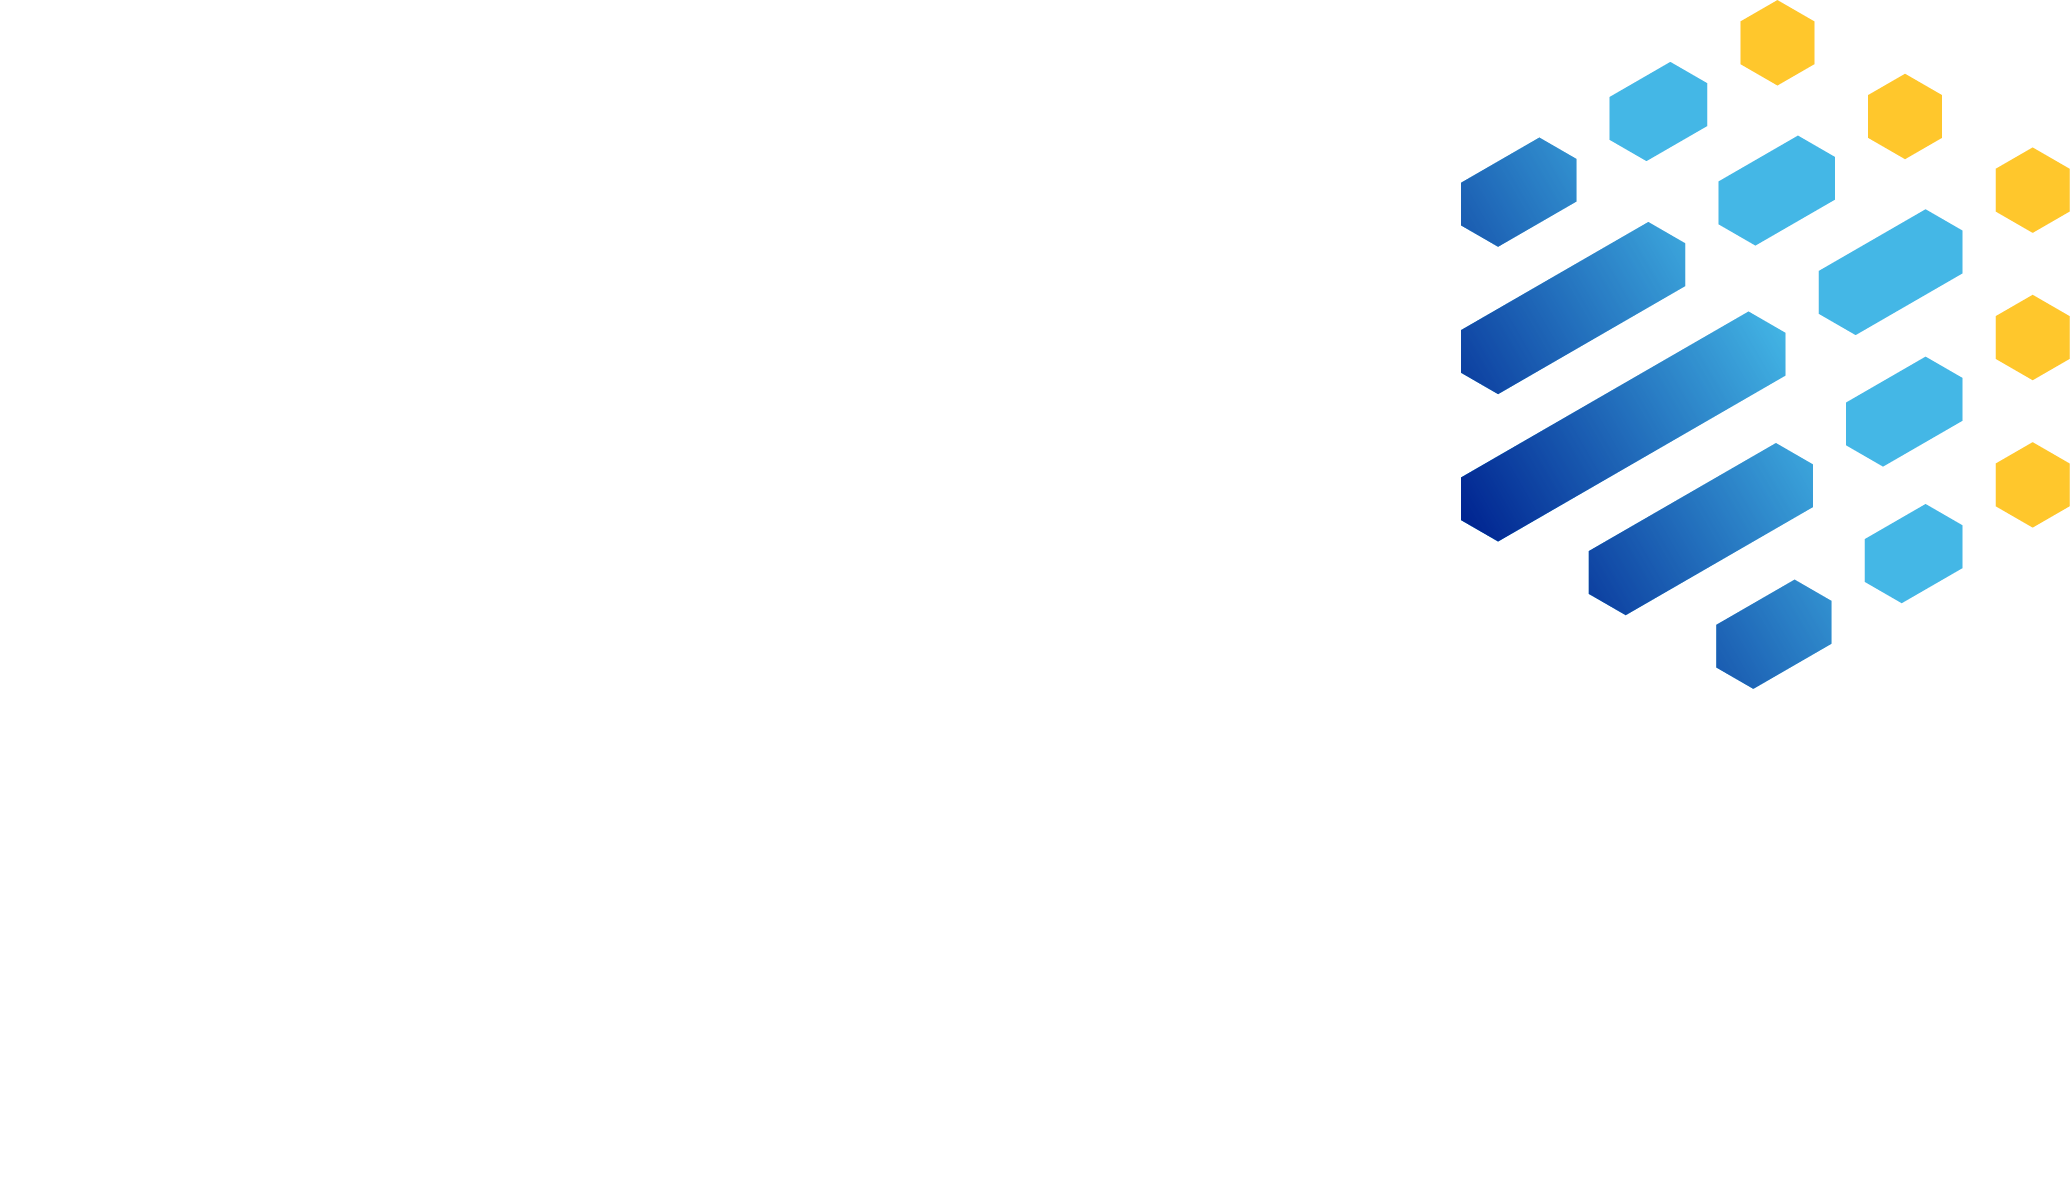
  <div style="color:#FFFFFF; font-size:18px; font-weight:700; font-family:Arial,Helvetica,sans-serif;">Authentication</div>
  <div style="color:#DCE6F5; font-size:14px; margin-top:6px; max-width:70ch;">OAuth 2.0 client-credentials flow through CAS's shared SSO service.</div>
</div>

The CAS GraphQL API uses **OAuth 2.0 client credentials flow** through CAS's shared SSO service — the same authorization layer used across CAS's API products.

## Credentials

You'll need a **Client ID** and **Client Secret**, issued by CAS Custom Services℠ when your organization's contract/access is set up. These are organization-level credentials, not per-user.

| | |
|---|---|
| Token endpoint | `https://sso.cas.org/as/token.oauth2` |
| Grant type | `client_credentials` |
| Scope | `content.read` |
| GraphQL endpoint | `https://lithium.cas.org/graphql` |
| Access token lifetime | 24 hours |

## Step 1 — request an access token

Run the cell below. It will prompt for your Client ID and Client Secret — the secret is masked as you type via `getpass`, and neither value is written to this notebook file.

In [ ]:
import http.client
import json
import getpass

client_id = input("CAS Client ID: ").strip()
client_secret = getpass.getpass("CAS Client Secret (input hidden): ").strip()

headers = {"Content-Type": "application/x-www-form-urlencoded"}
payload = (
    f"grant_type=client_credentials&client_id={client_id}"
    f"&scope=content.read&client_secret={client_secret}"
)

conn = http.client.HTTPSConnection("sso.cas.org")
conn.request("POST", "/as/token.oauth2", payload, headers)

response_json = json.loads(conn.getresponse().read().decode("utf-8"))
access_token = response_json["access_token"]
print(f"Token acquired, expires in {response_json.get('expires_in')}s. "
      f"(The token value itself is intentionally not printed.)")

<div style="border:1px solid rgba(5,28,44,0.14); border-left:4px solid #c07f00; background:#FBF0DA; border-radius:10px; padding:12px 16px; margin:14px 0;">
<strong>Note:</strong> Tokens last 24 hours. Cache and reuse the token rather than requesting a new one per call; re-request when it's close to expiring or when a request comes back <code>401</code>.
</div>

## Step 2 — call the GraphQL endpoint

Send the token as a `Bearer` credential in the `Authorization` header, and POST your query (and any variables) as JSON. This cell reuses `access_token` from the cell above and runs a real `documentQuery`.

In [ ]:
import requests
from pprint import pprint

endpoint_url = "https://lithium.cas.org/graphql"
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {access_token}",
}

query = """
query documentQuery($first: String = "", $last: String, $pageNumber: Int = 1, $pageSize: Int = 50) {
  documentQuery(
    documentInput: { person: { lastName: $last, firstName: $first } }
    pageParameters: { page: $pageNumber, pageSize: $pageSize }
  ) {
    documents {
      title
      conceptFindingPage {
        conceptFindings {
          concept {
            preferredName
          }
        }
      }
    }
    pageInformation {
      totalItems
    }
  }
}
"""
variables = {"first": "Susan", "last": "Olesik"}

response = requests.post(endpoint_url, json={"query": query, "variables": variables}, headers=headers)
response_json = response.json()
pprint(response_json)

## Troubleshooting

| Symptom | Likely cause |
|---|---|
| `401` from the token endpoint | Wrong `client_id` / `client_secret`. |
| `400 invalid_scope` | Your credentials aren't provisioned for `content.read` — contact CAS Custom Services℠. |
| `401` from the GraphQL endpoint | Token expired (24h) or the `Authorization` header isn't being sent on every request. |
| `403` from the GraphQL endpoint, with a message like `Access denied for field: <Type>.<field>` or `Access denied for input fields in <Type>: ...` | Your token is valid, but your account isn't entitled to that specific field, type, or input argument — this is a narrower, per-field authorization check that runs after authentication succeeds. Contact CAS Custom Services℠ to review what your provisioning covers. |

From here on, the domain notebooks (03+) use the shared `common/cas_api.py` helper instead of repeating this by hand — same flow, wrapped in one `graphql(query, variables)` call.

<div style="margin:16px 0;"><a href="00_Overview.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Overview</a><span style="display:inline-block; padding:5px 12px; border-radius:999px; background:#0032A0; color:#FFFFFF; font-size:12.5px; font-weight:700; margin:3px 4px 3px 0;">Authentication</span><a href="02_Using_GraphiQL.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Using GraphiQL</a><a href="03_Substance_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Substance</a><a href="04_Reaction_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Reaction</a><a href="05_Document_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Document</a><a href="06_Property_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Property</a><a href="07_Catalog_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Catalog</a><a href="08_Hazard_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Hazard</a><a href="09_Concept_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Concept</a><a href="10_Biosequence_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Biosequence</a><a href="11_Miscellaneous_Use_Cases.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Misc Use Cases</a><a href="12_Retrosynthesis_Example.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Retrosynthesis</a></div><hr style="border:none; border-top:1px solid rgba(5,28,44,0.14); margin:28px 0 14px;"><div style="color:#5A656C; font-size:12px;">CAS Registry&reg;, CAS Registry Number&reg;, CAS Commercial Sources&trade;, and CAS Custom Services&#8480; are marks of the American Chemical Society.</div>